# PB — Valor de negocio (gain curve, lift, umbral EV)

Notebook autocontenido: la lógica de valor de negocio está en celdas de este `.ipynb` (no en `src/`).

**Sprint 5 (sin reentrenar):** se carga `../models/final_model.pkl` (artefacto Sprint 4) y solo se ejecuta `predict_proba` sobre el **mismo** holdout: split `random_state=42`, `test_size=0.2`, estratificado — alineado con `export_sprint4_artifacts` y `14_final_validation`.

Si falta el `.pkl`, generarlo desde la raíz del repo: `python scripts/sprint4_export.py`.

**Datos:** `../data/processed/04_default_credit_features.csv` (desde la carpeta `notebooks/`).

## Moneda y supuestos económicos

- Todo el valor monetario que aparece más abajo se expresa en **USD (\$)** para lectura única en el ejemplo académico.
- Esos montos **no vienen del CSV**: el fichero tiene características de crédito y la etiqueta de morosidad; los **\$** son decisiones del negocio (riesgos, pérdidas esperadas, coste de colección, canales, reputación).
- Las funciones reproducen la idea vista en clase (y `sklearn.metrics.confusion_matrix` con clase positiva bien definida): en cada umbral contamos TP / FP / FN / TN con regla \(\hat{y}=1\) si \(\hat{p}=\mathtt{prob\_mora} \ge\) umbral.



## 1. Sprint 1 (`01_business.ipynb`) vs Sprint 4

| Criterio | Sprint 1 | Sprint 4 (test, mismo modelo) |
|----------|----------|--------------------------------|
| ROC-AUC | ≥ 0.70 | Ver salida al entrenar |
| Recall | Alto (menos FN) | Depende del umbral |
| F1 | Complementario | ~ típico con umbral 0.5 |

## 2. Matriz costo–beneficio (positivo = intervenir)

| Resultado | Parámetro (USD en el ejemplo) |
|-----------|-----------|
| TP | Beneficio cuando acertamos a un moroso (capturamos riesgo) |
| FP | Costo falsas alarmas (tratamos como riesgosos quien no lo es) |
| FN | Costo de no intervenir ante un moroso real |

**Valor esperado sobre el conjunto de prueba (regla anterior):**

\[
\text{EV} = b\cdot\text{TP} - c_{\text{FP}}\cdot\text{FP} - c_{\text{FN}}\cdot\text{FN}
\]

**(TN no entra)** si solo cuantificamos efectos cuando declaramos "intervenir" como positivo vs no.

Los **\$** definidos más abajo en código son **ilustrativos** (rótulos `\$`; calibrarlos en USD con financiamiento/risk). Una extrapolación anual sólo tiene sentido después de ese calibrado.


### Qué hace cada función (paso a paso)

1. **`gain_lift_table`**  
   - Ordena las observaciones de mayor a menor `y_score` (probabilidad estimada de morosidad).  
   - Para cada punto del ranking calcula: fracción de población ya cubierta (`pct_population`), fracción de morosos reales capturados hasta ese punto (`pct_positives_captured`), y **lift** = esa fracción positivos / fracción población (comparado con elegir al azar la misma proporción). Sirve para ver si el modelo concentra malos en la cola del score.

2. **`confusion_at_threshold`**  
   - Convierte probabilidades en \( \hat{y}_i = \mathbb{1}\{\text{score}_i \ge t\} \).  
   - Cuenta manualmente TN, FP, FN, TP. Es equivalente en espíritu a `confusion_matrix(y_true, y_pred, labels=[0,1])` si `y_pred` se deriva del mismo umbral (convención: positivo = intervenir).

3. **`expected_net_value`**  
   - Aplica la fórmula de la celda anterior: suma ponderada solo de TP, FP y FN (el costo/beneficio de TN lo hemos omitido por simplicidad en el ejemplo).

4. **`threshold_search_ev`**  
   - Prueba una rejilla de umbrales (por defecto: 0, todos los scores únicos ordenados, y 1).  
   - Para cada umbral guarda TP, FP, FN, TN y EV. Así vemos cómo cambia el valor de negocio al mover el punto de corte.

5. **`best_threshold_ev`**  
   - Devuelve el umbral que **maximiza** `net_value` en esa tabla y el `DataFrame` completo por si queremos graficar o auditar filas.



In [1]:
import numpy as np
import pandas as pd


def gain_lift_table(y_true: np.ndarray, y_score: np.ndarray) -> pd.DataFrame:
    """Tabla incremental: población ordenada por score (más riesgo arriba) y captura de positivos."""
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=float)
    # Índices que ordenan de mayor probabilidad predicha a menor
    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    n = len(y_true)
    pos_total = int(y_true.sum())
    if pos_total == 0:
        raise ValueError("y_true no contiene positivos (mora).")
    ranks = np.arange(1, n + 1)
    pct_population = ranks / n
    cum_pos = np.cumsum(y_sorted)
    pct_positives_captured = cum_pos / pos_total
    lift = pct_positives_captured / np.maximum(pct_population, 1e-12)
    return pd.DataFrame(
        {
            "rank": ranks,
            "pct_population": pct_population,
            "pct_positives_captured": pct_positives_captured,
            "lift_vs_random": lift,
        }
    )


def confusion_at_threshold(y_true: np.ndarray, y_score: np.ndarray, threshold: float):
    """Matriz de confusión explicitada; positivo modelo = score >= threshold (intervenir)."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    return tn, fp, fn, tp


def expected_net_value(
    tp: int, fp: int, fn: int, benefit_tp: float, cost_fp: float, cost_fn: float
) -> float:
    """EV = peso_TP * TP - peso_FP * FP - peso_FN * FN (montos deben estar en misma moneda, aquí USD)."""
    return tp * benefit_tp - fp * cost_fp - fn * cost_fn


def threshold_search_ev(
    y_true: np.ndarray,
    y_score: np.ndarray,
    benefit_tp: float,
    cost_fp: float,
    cost_fn: float,
    thresholds: np.ndarray | None = None,
) -> pd.DataFrame:
    """Barrido de umbrales: una fila por t con métricas y valor esperado económico."""
    y_score = np.asarray(y_score, dtype=float)
    if thresholds is None:
        thresholds = np.unique(np.concatenate([[0.0], np.sort(y_score), [1.0]]))
    rows = []
    for t in thresholds:
        tn, fp, fn, tp = confusion_at_threshold(y_true, y_score, t)
        ev = expected_net_value(tp, fp, fn, benefit_tp, cost_fp, cost_fn)
        rows.append(
            {
                "threshold": t,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "tn": tn,
                "net_value": ev,
            }
        )
    return pd.DataFrame(rows)


def best_threshold_ev(
    y_true: np.ndarray,
    y_score: np.ndarray,
    benefit_tp: float,
    cost_fp: float,
    cost_fn: float,
):
    """Umbral que maximiza net_value sobre la rejilla anterior."""
    df = threshold_search_ev(y_true, y_score, benefit_tp, cost_fp, cost_fn)
    best_idx = int(df["net_value"].idxmax())
    return float(df.loc[best_idx, "threshold"]), df


### Datos, mismo holdout que Sprint 4 y carga del modelo

1. **CSV de features** — `X` son variables; `y` es `default payment next month` (positivo = mora). Se elimina `ID` como en el resto del proyecto.  
2. **`train_test_split`** — Réplica del contrato de validación: `test_size=0.2`, estratificado sobre `y`, `random_state=42`. Los nombres `_X_train`, `_y_train` dejan claro que este notebook **no** usa el train para ajustar el modelo.  
3. **`final_model.pkl`** — Pipeline o estimador serializado en Sprint 4. Aquí solo `joblib.load` + `predict_proba` → columna 1 = \(P(\text{mora}\mid x)\).  
4. **Error si falta el `.pkl`** — Evita un `fit` oculto por accidente; hay que generar el artefacto con el script indicado en la introducción.


In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# Sprint 5: inferencia únicamente (modelo final Sprint 4).
TARGET = "default payment next month"
MODEL_PATH = Path("../models/final_model.pkl")

df = pd.read_csv("../data/processed/04_default_credit_features.csv")
df = df.drop(columns=["ID"])
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Holdout alineado con export / 14_final_validation (no re-entrenamos aquí).
_X_train, X_test, _y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

if not MODEL_PATH.is_file():
    raise FileNotFoundError(
        f"No existe {MODEL_PATH.resolve()}. Genera el artefacto desde la raíz del repo con:\n"
        "  python scripts/sprint4_export.py"
    )

final_model = joblib.load(MODEL_PATH)
# Probabilidad clase positiva (mora); el umbral económico opera sobre este vector.
y_proba = final_model.predict_proba(X_test)[:, 1]
print(
    "Modelo cargado (Sprint 4), sin .fit en este notebook; "
    "y_proba lista para valor de negocio."
)


Modelo cargado (Sprint 4), sin .fit en este notebook; y_proba lista para valor de negocio.


### Gain curve, lift y umbral económico (holdout)

- **gain / lift**: con `gain_lift_table` vemos cómo crece la captura de moros si priorizamos a los clientes por `prob_mora` de mayor a menor.
- **`best_threshold_ev`**: elige \(t\) que maximiza \(\text{EV} = b\cdot TP - c_{\text{FP}} FP - c_{\text{FN}} FN\) en la rejilla de umbrales; misma convención que en clase para positivo = “intervenir” si `prob_mora ≥ t`.
- **Umbral 0.5**: comparación habitual con el corte sklearn por defecto; la matriz manual encaja con `confusion_matrix(..., labels=[0, 1])` si `y_pred = (y_proba >= t).astype(int)`.
- **USD ($)**: los tres escalares económicos de la siguiente celda **no están en los datos**: son placeholders hasta que financiamiento/riesgo definan pérdidas evitadas y costos de tratamiento/errar.


=== Gain / lift (top 20 % ordenados por score) ===
Fracción población: 0.200
Fracción morosos capturados: 0.503
Lift vs. azar: 2.513x


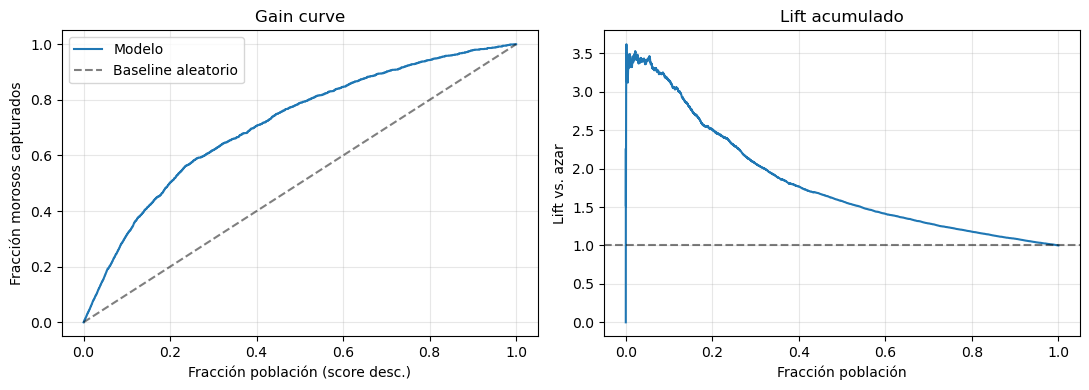


=== Umbral óptimo EV ===
Umbral*: 0.2271
threshold     0.22708
tp             1326.0
fp             4595.0
fn                1.0
tn               78.0
net_value    657010.0
Name: 80, dtype: object

=== Impacto anual estimado (extrapolación lineal) ===
Net test (umbral*): $657,010 USD
Net anual (~600,000 cuentas): $65,701,000 USD (escala proporcional solo si calibraron $ y volumen).
Net test (umbral 0.5): $33,420 USD

=== Sensibilidad ±30 % ===


x0.7: umbral*=0.2271, net_anual≈$45,990,700 USD


x1.0: umbral*=0.2271, net_anual≈$65,701,000 USD


x1.3: umbral*=0.2271, net_anual≈$85,411,300 USD

=== Supuestos ===
- Montos ($) y N_ANNUAL no vienen del CSV; son placeholders para el informe PB.
- La extrapolación lineal sólo vale si la cartera anual tiene perfil cercano al holdout.


In [3]:
# --- USD ($) solo como ejemplo didáctico (no están en el CSV) ---
# Ajustar montos con riesgos/finanzas antes de extrapolar a decisiones operativas.
# Flujo de esta celda: (1) gain/lift y gráficos; (2) umbral óptimo por EV y fila óptima;
# (3) comparación económica con umbral por defecto 0.5. Para chequear contra sklearn:
#   from sklearn.metrics import confusion_matrix
#   confusion_matrix(y_test, (y_proba >= 0.5).astype(int), labels=[0, 1])
#   debe alinear tn, fp, fn, tp con confusion_at_threshold(..., 0.5).

# Equivalente ilustrativo a escala menor que los NT$ usados antes (~ factor ~1/30 en este ejemplo).
BENEFIT_TP = 600.0
COST_FP = 30.0
COST_FN = 740.0

N_TEST = len(y_test)
# Cuentas al año también es hipótesis (volumen de cartera típico de informe ejecutivo ficticio).
N_ANNUAL = 600_000

gl = gain_lift_table(y_test.values, y_proba)

k20 = max(1, int(0.20 * N_TEST)) - 1
row20 = gl.iloc[k20]
print("=== Gain / lift (top 20 % ordenados por score) ===")
print(f"Fracción población: {row20['pct_population']:.3f}")
print(f"Fracción morosos capturados: {row20['pct_positives_captured']:.3f}")
print(f"Lift vs. azar: {row20['lift_vs_random']:.3f}x")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(gl["pct_population"], gl["pct_positives_captured"], label="Modelo")
ax[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Baseline aleatorio")
ax[0].set_xlabel("Fracción población (score desc.)")
ax[0].set_ylabel("Fracción morosos capturados")
ax[0].set_title("Gain curve")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(gl["pct_population"], gl["lift_vs_random"])
ax[1].axhline(1.0, color="k", linestyle="--", alpha=0.5)
ax[1].set_xlabel("Fracción población")
ax[1].set_ylabel("Lift vs. azar")
ax[1].set_title("Lift acumulado")
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_t, ev_df = best_threshold_ev(y_test.values, y_proba, BENEFIT_TP, COST_FP, COST_FN)
best_row = ev_df.loc[ev_df["net_value"].idxmax()]
print("\n=== Umbral óptimo EV ===")
print(f"Umbral*: {best_t:.4f}")
print(best_row.astype(object))

tn0, fp0, fn0, tp0 = confusion_at_threshold(y_test.values, y_proba, 0.5)
ev_default = expected_net_value(tp0, fp0, fn0, BENEFIT_TP, COST_FP, COST_FN)
net_best = float(best_row["net_value"])
scale = N_ANNUAL / N_TEST

print("\n=== Impacto anual estimado (extrapolación lineal) ===")
print(f"Net test (umbral*): ${net_best:,.0f} USD")
print(
    f"Net anual (~{N_ANNUAL:,} cuentas): ${net_best * scale:,.0f} USD "
    "(escala proporcional solo si calibraron $ y volumen)."
)
print(f"Net test (umbral 0.5): ${ev_default:,.0f} USD")

print("\n=== Sensibilidad ±30 % ===")
for f in (0.7, 1.0, 1.3):
    b, cf, cn = BENEFIT_TP * f, COST_FP * f, COST_FN * f
    t_star, _ = best_threshold_ev(y_test.values, y_proba, b, cf, cn)
    _, fp, fn, tp = confusion_at_threshold(y_test.values, y_proba, t_star)
    nv = expected_net_value(tp, fp, fn, b, cf, cn)
    print(f"x{f:.1f}: umbral*={t_star:.4f}, net_anual≈${nv * scale:,.0f} USD")

print("\n=== Supuestos ===")
print("- Montos ($) y N_ANNUAL no vienen del CSV; son placeholders para el informe PB.")
print("- La extrapolación lineal sólo vale si la cartera anual tiene perfil cercano al holdout.")
